## Description

**rodeo** is a Python library that uses [probabilistic numerics](http://probabilistic-numerics.org/) to solve ordinary differential equations (ODEs).  That is, most ODE solvers (such as [Euler's method](https://en.wikipedia.org/wiki/Euler_method)) produce a deterministic approximation to the ODE on a grid of size $\delta$.  As $\delta$ goes to zero, the approximation converges to the true ODE solution.  Probabilistic solvers such as **rodeo** also output a solution an a grid of size $\delta$; however, the solution is random.  Still, as $\delta$ goes to zero we get the correct answer.

**rodeo** provides a probabilistic solver for univariate process x(t) of the form

\begin{equation*}
  \WW \xx(t) = f(\xx(t), t), \qquad t \in [a, b], \quad \xx(0) = \vv,
\end{equation*}

where $\xx(t) = \big(x^{(0)}(t), x^{(1)}(t), ..., x^{(q)}(t)\big)$ consists of $x(t)$ and its first $q$ derivatives, $\WW$ is a coefficient matrix, and $f(\xx(t), t)$ is typically a nonlinear function.

**rodeo** implements the probabilistic solver of [Chkrebtii et al (2016)](https://projecteuclid.org/euclid.ba/1473276259).  This begins by putting a [Gaussian process](https://en.wikipedia.org/wiki/Gaussian_process) prior on the ODE solution, and updating it sequentially as the solver steps through the grid.

## Walkthrough


To illustrate the set-up, let's consider the following ODE example (**FitzHugh-Nagumo** model) where $q=1$ for both variables:

\begin{align*}
  \frac{dV}{dt} &= c(V - \frac{V^3}{3} + R), \\
  \frac{dR}{dt} &= -\frac{(V - a - bR)}{c}, \\
  \xx_0 &= (V(0), R(0)) = (-1,1).
\end{align*}

where the solution $x(t)$ is sought on the interval $t \in [0, 40]$ and $\theta = (a,b,c) = (.2,.2,3)$.  

To approximate the solution with the probabilistic solver, the Gaussian process prior we will use is a so-called [Continuous Autoregressive Process](https://CRAN.R-project.org/package=cts/vignettes/kf.pdf) of order $p$. A particularly simple $\car(p)$ proposed by [Schober](http://link.springer.com/10.1007/s11222-017-9798-7) is the $p-1$ times integrated Brownian motion, 

\begin{equation*}
  \xx(t) \sim \ibm(p).
\end{equation*}

Here $\xx(t)  = (x^{(0)}(t), ..., x^{(p-1)}(t))$ consists of $x(t)$ and its first $p-1$ derivatives.
The $\ibm$ model specifies that each of $\xx(t)  = (x^{(0)}(t), ..., x^{(p-1)}(t))$ is continuous, but $x^{(p)}(t)$ is not. Therefore, we need to pick $p > q$. It's usually a good idea to have $p$ a bit larger than $q$, especially when we think that the true solution $x(t)$ is smooth. However, increasing $p$ also increases the computational burden, and doesn't necessarily have to be large for the solver to work.  For this example, we will use $p=3$. To initialize, we simply set $\xx(0) = (\xx_0, 0)$. The Python code to implement all this is as follows. 

In [33]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

from rodeo.ibm import ibm_init
from rodeo.ode import *
from jax.config import config
config.update("jax_enable_x64", True)

In [34]:
def ode_fun_jax(X_t, t, theta):
    "FitzHugh-Nagumo ODE."
    a, b, c = theta
    V, R = X_t[:,0]
    return jnp.array([[c*(V - V*V*V/3 + R)],
                    [-1/c*(V - a + b*R)]])


# problem setup and intialization
n_deriv = 1  # Total state
n_obs = 2  # Total observations
n_deriv_prior = 3

# it is assumed that the solution is sought on the interval [tmin, tmax].
n_eval = 800
tmin = 0.
tmax = 40.
theta = jnp.array([0.2, 0.2, 3])

# The rest of the parameters can be tuned according to ODE
# For this problem, we will use
sigma = .01
sigma = jnp.array([sigma]*n_obs)

# Initial W for jax block
W_mat = np.zeros((n_obs, 1, n_deriv_prior))
W_mat[:, :, 1] = 1
W_block = jnp.array(W_mat)

# Initial x0 for jax block
x0_block = jnp.array([[-1., 1., 0.], [1., 1/3, 0.]])

# Get parameters needed to run the solver
dt = (tmax-tmin)/n_eval
n_order = jnp.array([n_deriv_prior]*n_obs)
ode_init = ibm_init(dt, n_order, sigma)

# Jit solver
key = jax.random.PRNGKey(0)
mv_jit = jax.jit(solve_sim, static_argnums=(1, 6))
xt = mv_jit(key=key, fun=ode_fun_jax,
        x0=x0_block, theta=theta,
        tmin=tmin, tmax=tmax, n_eval=n_eval,
        wgt_meas=W_block, **ode_init)


To compare the `rodeo` solution, we use the deterministic solution provided by `odeint`.

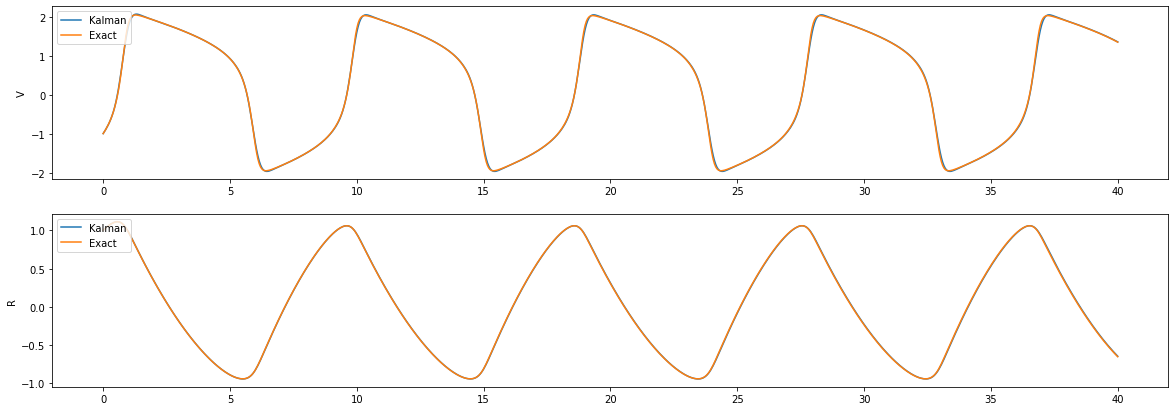

In [36]:
def ode_fun(X_t, t, theta):
    a, b, c = theta
    V, R = X_t
    return np.array([c*(V - V*V*V/3 + R), -1/c*(V - a + b*R)])

# Initial x0 for odeint
ode0 = np.array([-1., 1.])

# Get odeint solution for Fitz-Hugh
tseq = np.linspace(tmin, tmax, n_eval+1)
exact = odeint(ode_fun, ode0, tseq, args=(theta,))

# Graph the results
_, axs = plt.subplots(2, 1, figsize=(20, 7))
ylabel = ['V', 'R']
for i in range(2):
    axs[i].plot(tseq, xt[:, i, 0], label="Kalman")
    axs[i].set_ylabel(ylabel[i])
    axs[i].plot(tseq, exact[:, i], label='Exact')
    axs[i].legend(loc='upper left')